# TP 2 - Exercice 1

**Prénom et nom : Hamadou BA**

## Exercice 1 - Régression linéaire univarié 
Les données utilisées pour cet exercice décrivent les tailles d'enfants d'âge compris entre 2 et 8 ans : le fichier `ex1x.dat` correspond à leur âge et `ex1y.dat` correspond à leur taille (en mètres). On a dans ces 2 fichiers, les données de 50 enfants rangées dans le même ordre. 

Ces données constituent des exemples d'apprentissage qui vont être utilisées afin de construire un modèle de régression linéaire qui a pour objectif de prédire la taille d'un enfant à partir de son âge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

1. Tout d'abord, nous allons utiliser la fonction `loadtxt`du package `numpy`en Python (ici désigné par `np`). Cette fonction permet de lire les fichiers et de les concertir en vecteurs/matrices :
```
    x=np.loadtxt('ex1x.dat');
    y=np.loadtxt('ex1y.dat');
``` 

In [2]:
x = np.loadtxt('ex1x.dat')
y = np.loadtxt('ex1y.dat')
m = len(x)          # nombre d'exemples d'apprentissage
print('x :', x.shape, ' y :', y.shape)
print('âges   :', x[:5])
print('tailles :', y[:5])

x : (50,)  y : (50,)
âges   : [2.0658746 2.3684087 2.5399929 2.5420804 2.549079 ]
tailles : [0.77918926 0.91596757 0.90538354 0.90566138 0.9389889 ]


**Réponse :** on obtient deux vecteurs de $m=50$ valeurs : les âges $x$ (entre 2 et 8 ans) et les tailles $y$ (en mètres), rangés dans le même ordre.

2. Afficher le nuage de points $(x_i,y_i)$.

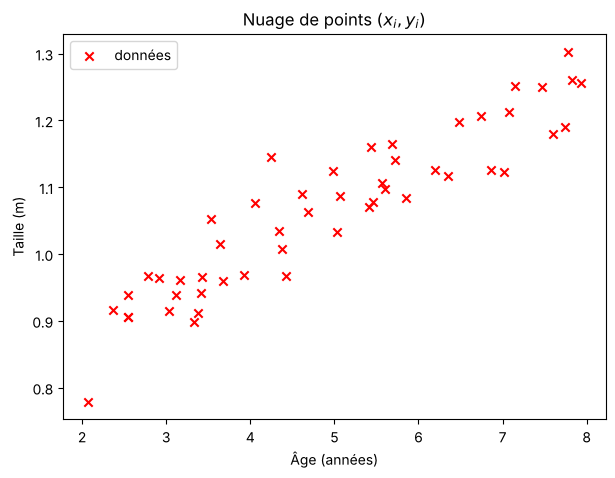

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, c='r', marker='x', label='données')
plt.xlabel('Âge (années)')
plt.ylabel('Taille (m)')
plt.title('Nuage de points $(x_i, y_i)$')
plt.legend()
plt.show()

**Réponse :** les points s'alignent approximativement le long d'une droite croissante : la taille augmente avec l'âge. Un modèle de régression linéaire est donc adapté.

3. Définir en Python, la fonction hypothèse correspondant à un modèle de régression linéaire. Soit le vecteur $\theta = (\theta_0, \theta_1)$, cette fonction hypothèse s'écrit 
$$
h(\theta_0, \theta_1, x) = \theta_0 + \theta_1 x
$$

In [4]:
def h(theta0, theta1, x):
    """Fonction hypothèse : h(theta0, theta1, x) = theta0 + theta1 * x"""
    return theta0 + theta1 * x

**Réponse :** $h$ fonctionne aussi bien pour un réel que pour un vecteur `numpy` $x$ (calcul composante par composante).

4. Définir en Python, la fonction de coût $J(\theta_0, \theta_1)$ telle que vue en cours.

In [5]:
def J(theta0, theta1):
    """Fonction de coût (critère des moindres carrés) : J = 1/(2m) * somme (h(x_i) - y_i)^2"""
    return np.sum((h(theta0, theta1, x) - y) ** 2) / (2 * m)

print('J(0, 0) =', J(0, 0))

J(0, 0) = 0.5737324907367211


**Réponse :** $J(\theta_0,\theta_1)=\dfrac{1}{2m}\displaystyle\sum_{i=1}^{m}\big(\theta_0+\theta_1x_i-y_i\big)^2$. Au point de départ $\theta=(0,0)$, on a $J\approx0{,}574$.

5. Définir en Python, une fonction qui réalise une itération et qui va renvoyer $\theta_0^*$ et $\theta_1^*$, en fonction de $\theta_0$ et $\theta_1$, selon les formules de descente de gradient vue en cours.  
Pour faire fonctionner cette méthode de gradient, il faut définir la valeur du coefficient d'apprentissage noté $\alpha$ dans le cours ; il régle la profondeur de descente. On propose ici que ce coefficient prenne une valeur constante égale à 0,07. On partira aussi des valeurs initiales $\theta_0=\theta_1=0$.

In [6]:
alpha = 0.07   # coefficient d'apprentissage

def iteration(theta0, theta1):
    """Une itération de la descente de gradient : renvoie (theta0*, theta1*)"""
    e = h(theta0, theta1, x) - y                 # écarts h(x_i) - y_i
    theta0_star = theta0 - alpha / m * np.sum(e)
    theta1_star = theta1 - alpha / m * np.sum(e * x)
    return theta0_star, theta1_star              # mise à jour simultanée

print(iteration(0, 0))

(np.float64(0.07452802382200001), np.float64(0.38002167250780633))


**Réponse :** d'après le cours,
$\theta_0^*=\theta_0-\dfrac{\alpha}{m}\displaystyle\sum_{i=1}^{m}(h_\theta(x_i)-y_i)$ et
$\theta_1^*=\theta_1-\dfrac{\alpha}{m}\displaystyle\sum_{i=1}^{m}(h_\theta(x_i)-y_i)\,x_i$.
Les deux nouvelles valeurs sont calculées à partir des **anciennes** valeurs de $\theta_0$ et $\theta_1$ (mise à jour simultanée), puis on remplace $\theta$ par $\theta^*$ à l'itération suivante.

6. Faire tourner la méthode de descente de gradient sur quelques itérations puis représenter la droite 
$$
y= \theta_0 + \theta_1 x
$$
sur le nuage de points.

itération 1 : theta0 = 0.0745, theta1 = 0.3800, J = 0.5351
itération 2 : theta0 = 0.0129, theta1 = 0.0117, J = 0.4992
itération 3 : theta0 = 0.0825, theta1 = 0.3650, J = 0.4658
itération 4 : theta0 = 0.0254, theta1 = 0.0225, J = 0.4347
itération 5 : theta0 = 0.0904, theta1 = 0.3510, J = 0.4057


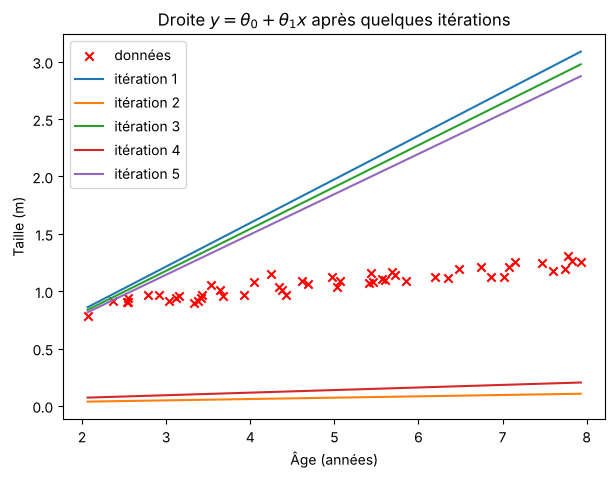

In [7]:
theta0, theta1 = 0.0, 0.0
xs = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, c='r', marker='x', label='données')
for k in range(1, 6):
    theta0, theta1 = iteration(theta0, theta1)
    print(f'itération {k} : theta0 = {theta0:.4f}, theta1 = {theta1:.4f}, J = {J(theta0, theta1):.4f}')
    plt.plot(xs, h(theta0, theta1, xs), label=f'itération {k}')
plt.xlabel('Âge (années)'); plt.ylabel('Taille (m)')
plt.title('Droite $y=\\theta_0+\\theta_1 x$ après quelques itérations')
plt.legend(); plt.show()

**Réponse :** après 5 itérations, $J$ a diminué ($0{,}574 \to 0{,}406$) mais la droite n'est pas encore ajustée. On observe que $\theta_1$ **oscille** : il vaut environ $0{,}38$ aux itérations impaires (droite beaucoup trop pentue) et environ $0{,}01$ aux itérations paires (droite presque horizontale, trop basse), tandis que $\theta_0$ augmente lentement ($\approx0{,}09$).

Avec $\alpha=0{,}07$ et des âges allant jusqu'à 8, le pas est assez grand dans la direction $\theta_1$ : la descente « rebondit » d'un bord à l'autre de la vallée de $J$, tout en descendant. Il faut poursuivre les itérations pour converger.

7. Faire tourner la méthode de descente de gradient pendant toutes les itérations nécessaires à faire converger la solution $\theta$ recherchée. Pour cela on définit le critère d'arrêt du processus itératif par
$$
\left\vert \dfrac{J(\theta^*)-J(\theta)}{J(\theta)}\right\vert < 10^{-10}
$$
Afficher la droite obtenue suite à cette convergence sur le nuage de points.

nombre d'itérations : 1512
theta0 = 0.7502   theta1 = 0.0639   J = 0.000987


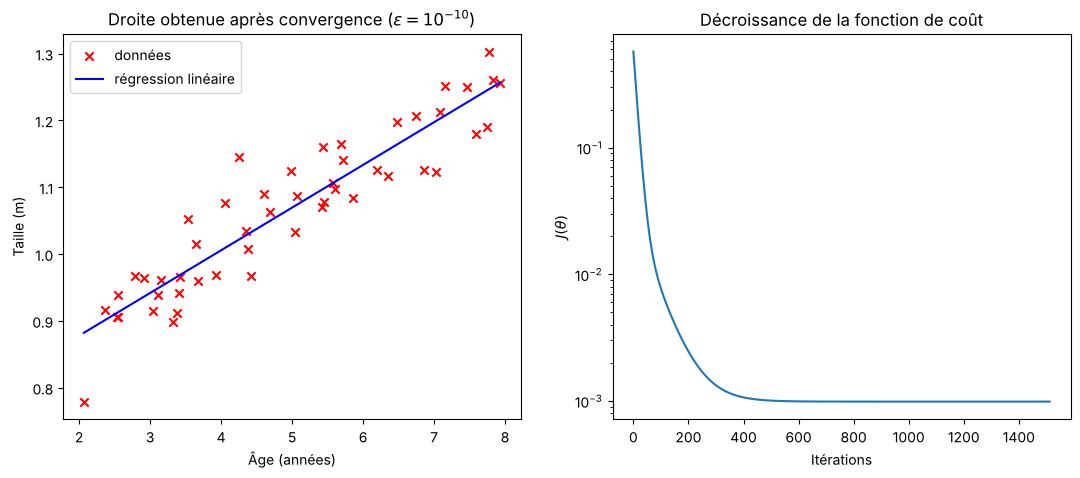

In [8]:
eps = 1e-10   # critère d'arrêt (seuil corrigé : 10^-10)

def descente(eps, theta0=0.0, theta1=0.0):
    """Itère jusqu'à |J(theta*) - J(theta)| / J(theta) < eps ; renvoie theta0, theta1, nb d'itérations, historique de J"""
    hist = [J(theta0, theta1)]
    while True:
        theta0, theta1 = iteration(theta0, theta1)
        hist.append(J(theta0, theta1))
        if abs((hist[-1] - hist[-2]) / hist[-2]) < eps:
            return theta0, theta1, len(hist) - 1, hist

theta0, theta1, n_iter, hist = descente(eps)
print("nombre d'itérations :", n_iter)
print(f'theta0 = {theta0:.4f}   theta1 = {theta1:.4f}   J = {J(theta0, theta1):.6f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(x, y, c='r', marker='x', label='données')
ax[0].plot(xs, h(theta0, theta1, xs), 'b', label='régression linéaire')
ax[0].set_xlabel('Âge (années)'); ax[0].set_ylabel('Taille (m)')
ax[0].set_title('Droite obtenue après convergence ($\\varepsilon=10^{-10}$)'); ax[0].legend()
ax[1].plot(hist)
ax[1].set_yscale('log'); ax[1].set_xlabel('Itérations'); ax[1].set_ylabel('$J(\\theta)$')
ax[1].set_title('Décroissance de la fonction de coût')
plt.show()

**Réponse :** avec le critère d'arrêt $\left|\frac{J(\theta^*)-J(\theta)}{J(\theta)}\right|<10^{-10}$, l'algorithme s'arrête après **1512 itérations** avec $\theta_0\approx0{,}7502$ et $\theta_1\approx0{,}0639$. La droite passe bien au milieu du nuage de points et $J$ décroît de façon monotone.

Interprétation : $\theta_1\approx0{,}064$ signifie qu'un enfant grandit d'environ 6,4 cm par an sur cette tranche d'âge.

**Remarque sur la précision du critère d'arrêt.** Le critère porte sur la variation *relative* de $J$ entre deux itérations, pas sur la distance à l'optimum. Comme la « vallée » de $J$ est très allongée (voir question 9), la décroissance est lente en fin de calcul : un seuil trop grand (par exemple $10^{-3}$) arrêterait l'algorithme avant le minimum. C'est pourquoi on prend $\varepsilon=10^{-10}$. Le tableau ci-dessous compare plusieurs seuils avec la solution exacte des moindres carrés (`np.polyfit`) :

In [9]:
print(f"{'epsilon':>8} | {'itérations':>10} | {'theta0':>8} | {'theta1':>8} | {'J':>10}")
for e in (1e-3, 1e-6, 1e-10):
    t0, t1, n, _ = descente(e)
    print(f'{e:>8.0e} | {n:>10} | {t0:>8.4f} | {t1:>8.4f} | {J(t0, t1):>10.7f}')
t1_ex, t0_ex = np.polyfit(x, y, 1)
print(f"{'exacte':>8} | {'-':>10} | {t0_ex:>8.4f} | {t1_ex:>8.4f} | {J(t0_ex, t1_ex):>10.7f}")

 epsilon | itérations |   theta0 |   theta1 |          J
   1e-03 |        407 |   0.7139 |   0.0705 |  0.0010580
   1e-06 |        883 |   0.7490 |   0.0641 |  0.0009871
   1e-10 |       1512 |   0.7502 |   0.0639 |  0.0009871
  exacte |          - |   0.7502 |   0.0639 |  0.0009871


**Réponse :** plus $\varepsilon$ est petit, plus $\theta$ se rapproche de la solution exacte $(0{,}7502 ;\ 0{,}0639)$, au prix de plus d'itérations. Avec $\varepsilon=10^{-3}$, on s'arrête après 407 itérations à $\theta\approx(0{,}714 ;\ 0{,}0705)$, avec un coût $J$ 7 % au-dessus du minimum. Avec $\varepsilon=10^{-10}$, $\theta$ coïncide avec la solution exacte à $10^{-4}$ près : c'est ce $\theta$ que l'on utilise pour la suite.

8. On peut désormais utiliser le modèle pour faire des prédictions : quelle est la taille de 3 enfants d'âges respectifs 3, 5 et 7 ans ?

In [10]:
for age in (3, 5, 7):
    print(f'âge {age} ans  ->  taille prédite : {h(theta0, theta1, age):.3f} m')

âge 3 ans  ->  taille prédite : 0.942 m
âge 5 ans  ->  taille prédite : 1.070 m
âge 7 ans  ->  taille prédite : 1.197 m


**Réponse :** avec $\theta=(0{,}7502 ;\ 0{,}0639)$ :

| Âge | Taille prédite |
|---|---|
| 3 ans | **0,942 m** |
| 5 ans | **1,070 m** |
| 7 ans | **1,197 m** |

(Ce sont aussi, au millimètre près, les valeurs données par la solution exacte.)

9. Nous allons maintenant visualiser la fonction de coût $J(\theta)$ en 3D sur une grille de base 100 x 100 et des valeurs pour $\theta$ dans les intervalles suivants (il faudra donc prendre 100 valeurs réparties dans ces intervalles) : $\theta_0 \in [-30;30]$ et $\theta_1 \in [-3;3]$.  

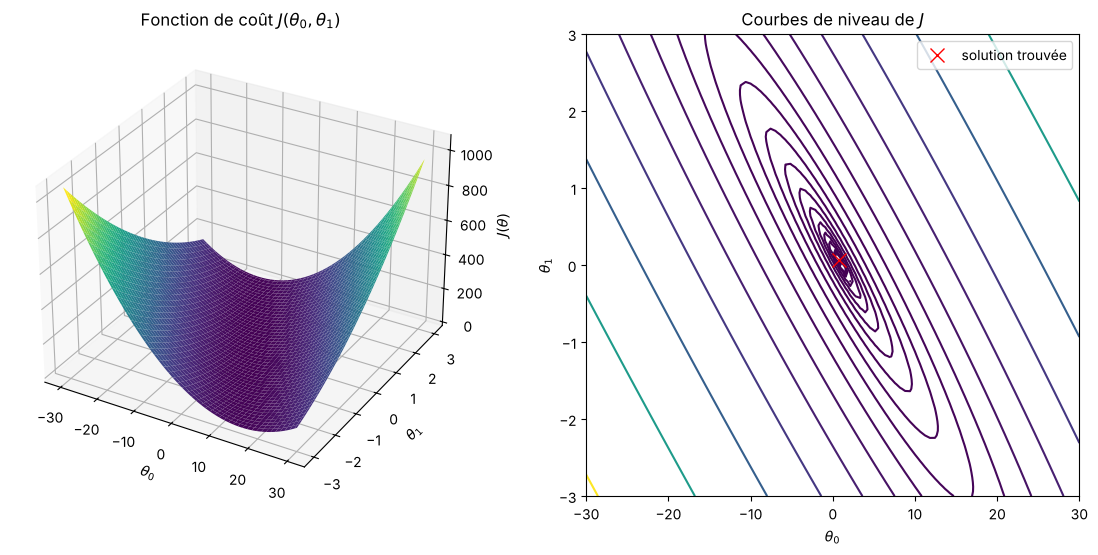

In [11]:
theta0_vals = np.linspace(-30, 30, 100)
theta1_vals = np.linspace(-3, 3, 100)
J_vals = np.zeros((100, 100))
for i, t0 in enumerate(theta0_vals):
    for j, t1 in enumerate(theta1_vals):
        J_vals[j, i] = J(t0, t1)          # ligne : theta1, colonne : theta0
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='viridis')
ax.set_xlabel('$\\theta_0$'); ax.set_ylabel('$\\theta_1$'); ax.set_zlabel('$J(\\theta)$')
ax.set_title('Fonction de coût $J(\\theta_0, \\theta_1)$')

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(T0, T1, J_vals, levels=np.logspace(-2, 3, 20))
ax2.plot(theta0, theta1, 'rx', markersize=10, label='solution trouvée')
ax2.set_xlabel('$\\theta_0$'); ax2.set_ylabel('$\\theta_1$')
ax2.set_title('Courbes de niveau de $J$'); ax2.legend()
plt.show()

**Réponse :** la surface $J(\theta_0,\theta_1)$ a la forme d'une **cuvette** (paraboloïde) : la fonction de coût des moindres carrés est convexe et possède un **unique minimum**, situé au point trouvé par la descente de gradient (croix rouge). Il n'y a donc pas de minimum local piège : la descente de gradient converge vers le minimum global.

Les courbes de niveau sont des ellipses très allongées : $J$ varie beaucoup selon $\theta_1$ et très peu selon $\theta_0$. C'est pour cela que la convergence est lente (des centaines d'itérations) et qu'il faut un critère d'arrêt très petit ($10^{-10}$) pour atteindre le fond de la vallée.